# Desafio 3: Optimización de despliegue PON

Integrantes:
* Camila Herrera
* Gustavo Venegas
* Javier Cáceres

## Secciones del Jupyter

1. Preparar herramientas (instalaciones e imports).
2. Extraer topología de OPenStreetMap (OSMnx).
3. Formular y resolver un ILP (PuLP) para ubicación de splitters y asignación de usuarios.
4. Validar presupuesto óptico y latencia.
5. Implementar funciones y ejemplos de ejecución.

## 1. Preparación: Instalación e imports

In [1]:
# Celda de setup: instalar paquetes (ejecutar solo si es necesario)
# Crear enviroment con: python3 -m venv wdm
# !pip install osmnx networkx geopandas shapely pulp matplotlib

# Imports necesarios
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
from shapely.geometry import Point
import heapq
from sklearn.cluster import KMeans   # si no tienes sklearn, instala scikit-learn

# Parámetros globales (se pueden ajustar)
COST_FIBER_PER_M = 1.0 # coste por metro (unidad monetaria arbitraria)
COST_SPLITTER = 200.0 # coste por splitter
SPLIT_RATIO = 32 # ratio típico 1:32
RMAX = 10000.0 # alcance máximo admisible (m). Ajustar según presupuesto óptico
FIBER_ATTEN_DB_PER_KM = 0.35
CONNECTOR_LOSS_DB = 0.5 # pérdida por conector (estimada)
SPLITTER_LOSS_TABLE = {2:3.5, 4:7.0, 8:10.5, 16:13.5, 32:17.5} # valores típicos de referencia

# Mostrar versión de paquetes
print('osmnx', ox.__version__)
print('networkx', nx.__version__)

osmnx 2.0.6
networkx 3.5


## 2. Extracción topológica y generación de usuarios

In [2]:
# Definir área de interés. Cambiar por otra ciudad/área si se desea.
place_name = 'Valparaíso, Chile'

# Descargar la red vial (driving network) y proyectar a CRS métrico
G = ox.graph_from_place(place_name, network_type='drive')
G = ox.project_graph(G)

# Obtener nodos como GeoDataFrame (índice = ID real del grafo)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

# Asegurarnos de que el índice sea del mismo tipo que G.nodes
assert set(nodes_gdf.index) == set(G.nodes), "Los índices de nodes_gdf no coinciden con G.nodes"

# Generar usuarios sintéticos directamente a partir de los índices válidos
num_users_example = 50
user_node_ids = np.random.choice(nodes_gdf.index, size=num_users_example, replace=False)

# Crear GeoDataFrame de usuarios basado en esos nodos
users_gdf = nodes_gdf.loc[user_node_ids, ['x', 'y']].copy()
users_gdf['geometry'] = users_gdf.apply(lambda r: Point(r.x, r.y), axis=1)
users_gdf = gpd.GeoDataFrame(users_gdf, geometry='geometry', crs=nodes_gdf.crs)
users_gdf['node_id'] = users_gdf.index  # estos índices son los IDs válidos del grafo

# Seleccionar candidatos a splitter: intersecciones con grado >= 3
candidate_nodes = nodes_gdf[nodes_gdf['street_count'] >= 3].copy()
candidate_nodes['node_id'] = candidate_nodes.index

print('Nodos totales:', len(nodes_gdf))
print('Usuarios muestreados:', len(users_gdf))
print('Nodos candidatos a splitter:', len(candidate_nodes))

Nodos totales: 7677
Usuarios muestreados: 50
Nodos candidatos a splitter: 5513


## 3. Precomputar rutas y distancias entre candidatos y usuarios

In [3]:
candidate_ids = list(candidate_nodes.index)
user_ids = list(users_gdf.index)

paths_edges = {}
path_lengths = {}

for u in user_ids:
    for s in candidate_ids:
        try:
            path_nodes = nx.shortest_path(G, source=s, target=u, weight='length')
            path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
            length = sum(
                G.get_edge_data(e[0], e[1])[0].get('length', 0)
                if isinstance(G.get_edge_data(e[0], e[1]), dict)
                else G.get_edge_data(e[0], e[1]).get('length', 0)
                for e in path_edges
            )
            paths_edges[(u, s)] = path_edges
            path_lengths[(u, s)] = length
        except (nx.NetworkXNoPath, KeyError):
            continue

print("Precomputadas rutas para pares user-candidate:", len(path_lengths))

Precomputadas rutas para pares user-candidate: 275150


In [4]:
# ------------------ BLOQUE 3.5: PODA Y FILTRADO PARA REDUCIR MODELO ------------------

# 0) Parámetros de poda (ajusta según memoria y tiempo)
MAX_CANDIDATES = 500   # máximo nodos candidatos que queremos mantener (reduce a 300/200 si es necesario)
K_NEAREST = 30         # número de candidatos más cercanos a considerar por usuario
USE_CLUSTERING = False # True si quieres agrupar usuarios y resolver por clusters (opcional)
N_CLUSTERS = 30        # si clustering=True, número de clusters a usar (reduce usuarios)

print("Antes: candidatos totales =", len(candidate_nodes), "pares (u,s) totales =", len(path_lengths))

# 1) Reducir candidatos por grado o por densidad:
# Tomamos los MAX_CANDIDATES nodos con mayor street_count (nodos con mayor conectividad suelen ser buenos splitters).
if len(candidate_nodes) > MAX_CANDIDATES:
    candidate_nodes = candidate_nodes.nlargest(MAX_CANDIDATES, 'street_count')
candidate_ids = list(candidate_nodes.index)
print("Tras poda candidatos:", len(candidate_ids))

# 2) (Opcional) Clustering de usuarios para reducir número de "centros" a asignar
if USE_CLUSTERING and len(users_gdf) > N_CLUSTERS:
    # Usamos coordenadas proyectadas (x,y)
    coords = np.vstack([users_gdf.geometry.x.values, users_gdf.geometry.y.values]).T
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0).fit(coords)
    users_gdf['cluster'] = kmeans.labels_
    # Definimos "usuarios representativos" como centroides (nuevos usuarios reducidos)
    centroids = kmeans.cluster_centers_
    users_reduced = []
    for i, (cx, cy) in enumerate(centroids):
        users_reduced.append({'node_id': f'cluster_{i}', 'x': cx, 'y': cy, 'geometry': Point(cx, cy)})
    users_reduced_gdf = gpd.GeoDataFrame(users_reduced, geometry='geometry', crs=users_gdf.crs)
    # Reemplazar el conjunto de usuarios por los centroides
    users_gdf = users_reduced_gdf
    user_ids = list(users_gdf['node_id'])
    print("Usuarios reducidos por clustering a:", len(user_ids))
else:
    # mantener user_ids previamente definidos
    user_ids = list(users_gdf.index)

# 3) Filtrar pares (u,s) manteniendo solo K_NEAREST por usuario (reduce drásticamente variables zu)
filtered_path_lengths = {}
filtered_paths_edges = {}

# Para distancia usamos path_lengths calculadas previamente. Si faltan algunas combinaciones
# (porque candidate_ids se redujo), sólo consideramos (u,s) donde exista la ruta.
for u in user_ids:
    # encontrar todos (u,s) disponibles en path_lengths
    available = [(path_lengths[(u,s)], s) for (uu,s) in path_lengths.keys() if uu == u and s in candidate_ids]
    if not available:
        # si no hay candidatos alcanzables para este usuario, lo notificamos (y lo dejamos sin par)
        print(f"Advertencia: usuario {u} no tiene candidatos alcanzables tras poda.")
        continue
    # escoger los K más cercanos
    k_nearest = heapq.nsmallest(min(K_NEAREST, len(available)), available, key=lambda x: x[0])
    for length, s in k_nearest:
        filtered_path_lengths[(u, s)] = length
        filtered_paths_edges[(u, s)] = paths_edges[(u, s)]

# Reemplazamos las estructuras por las filtradas
path_lengths = filtered_path_lengths
paths_edges = filtered_paths_edges
feasible_pairs = list(path_lengths.keys())
print("Pares (u,s) tras filtrado K_NEAREST:", len(feasible_pairs))

# 4) Reconstruir la lista de aristas relevantes (sólo las que aparecen en los pares filtrados)
relevant_edges = set()
for edges in paths_edges.values():
    for e in edges:
        relevant_edges.add(e)
relevant_edges = list(relevant_edges)
print("Aristas relevantes tras filtrado:", len(relevant_edges))

# 5) (Opcional) Podar aún más: eliminar candidatos que ya no aparecen en feasible_pairs
used_candidate_ids = set([s for (u,s) in feasible_pairs])
candidate_ids = [s for s in candidate_ids if s in used_candidate_ids]
print("Candidatos usados tras filtrado:", len(candidate_ids))

# 6) Actualiza user_ids si alguno quedó sin pares factibles (filtrados)
used_user_ids = set([u for (u,s) in feasible_pairs])
user_ids = [u for u in user_ids if u in used_user_ids]
print("Usuarios usados tras filtrado:", len(user_ids))

# 7) Reconstruir mapas para el ILP (esto coincide con lo que el Bloque 4 espera)
edge_keys = relevant_edges
edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}
# NOTA: no recalculamos path_lengths/paths_edges: ya están filtrados.
# -----------------------------------------------------------------------------------


Antes: candidatos totales = 5513 pares (u,s) totales = 275150
Tras poda candidatos: 500
Pares (u,s) tras filtrado K_NEAREST: 1500
Aristas relevantes tras filtrado: 2356
Candidatos usados tras filtrado: 414
Usuarios usados tras filtrado: 50


## 4. Formulación ILP con PuLP

In [5]:
# 1) Helper robusto para obtener longitud de una arista (u,v)
def get_edge_length_safe(G, u, v):
    """
    Devuelve la longitud (metros) entre u y v.
    Si G es MultiDiGraph, revisa todas las claves y toma el mínimo (o 0 si no hay info).
    """
    ed = G.get_edge_data(u, v)
    if not ed:
        return 0.0
    # Si ed es un dict de atributos (Graph simple)
    if isinstance(ed, dict) and all(not isinstance(vv, dict) for vv in ed.values()):
        # ed tiene atributos directos
        return float(ed.get('length', 0.0))
    # Si es MultiGraph, ed es un dict: key -> attrdict
    lengths = []
    for key, attr in ed.items():
        if isinstance(attr, dict):
            lengths.append(float(attr.get('length', 0.0)))
    if lengths:
        return min(lengths)   # tomar el mínimo por seguridad
    return 0.0

# 2) (Opcional) Podar candidatos para acelerar: por ejemplo, quedarnos con los N candidatos más cercanos en media
# Habilitar esto para reducir el ILP en instancias grandes.
# MAX_CANDIDATES = 500
# candidate_ids = candidate_ids if len(candidate_ids) <= MAX_CANDIDATES else candidate_ids[:MAX_CANDIDATES]

# 3) Reconstruir edge_keys de forma determinística
edge_keys = set()
for edges in paths_edges.values():
    for e in edges:  # e es (u_node, v_node)
        edge_keys.add(e)
edge_keys = list(edge_keys)

# Mapa índice -> (u,v)
edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}

# 4) Mapa de longitudes por arista (robusto)
edge_length_map = {i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
                   for i in edge_index_to_edge.keys()}

# 5) Crear problema PuLP
prob = pulp.LpProblem('PON_Splitter_Placement', pulp.LpMinimize)

# Variables binarias para aristas y splitters (como antes)
xe = pulp.LpVariable.dicts('x_edge', (range(len(edge_keys))), cat='Binary')
ys = pulp.LpVariable.dicts('y_splitter', (candidate_ids), cat='Binary')

# 6) Crear variables zu sólo para pares factibles (los que existen en path_lengths)
feasible_pairs = list(path_lengths.keys())  # lista de tuplas (u,s) que sí tienen camino calculado
zu = pulp.LpVariable.dicts('assign', feasible_pairs, cat='Binary')

# 7) Objetivo: coste fibra + splitters
fiber_cost_expr = pulp.lpSum([COST_FIBER_PER_M * edge_length_map[i] * xe[i] for i in range(len(edge_keys))])
splitter_cost_expr = pulp.lpSum([COST_SPLITTER * ys[s] for s in candidate_ids])
prob += fiber_cost_expr + splitter_cost_expr

# 8) Restricciones

# 8.1) Cada usuario debe asignarse exactamente a 1 splitter — considerar sólo splitters con (u,s) factible
for u in user_ids:
    # lista de s tal que (u,s) en feasible_pairs
    feasible_s_for_u = [s for (uu,s) in feasible_pairs if uu == u]
    # si no hay ningún s factible, forzamos fallo explícito (por seguridad)
    if len(feasible_s_for_u) == 0:
        raise RuntimeError(f"No hay candidatos alcanzables para el usuario {u}")
    prob += pulp.lpSum([zu[(u,s)] for s in feasible_s_for_u]) == 1

# 8.2) Capacidad de splitter
for s in candidate_ids:
    feasible_u_for_s = [u for (u,ss) in feasible_pairs if ss == s]
    if feasible_u_for_s:
        prob += pulp.lpSum([zu[(u,s)] for u in feasible_u_for_s]) <= SPLIT_RATIO * ys[s]
    else:
        # si un candidato no tiene usuarios factibles, es inútil; podríamos omitir la variable ys[s]
        prob += ys[s] >= 0  # redundante pero evita errores en la indexación

# 8.3) Alcance físico ya aplicado cuando construimos feasible_pairs (si lo filtraste)
# Si no lo hiciste antes, añadimos la prohibición ahora:
for (u,s), length in list(path_lengths.items()):
    if length > RMAX:
        # si (u,s) está en feasible_pairs, eliminar/forzar 0
        if (u,s) in feasible_pairs:
            prob += zu[(u,s)] == 0

# 8.4) Conectividad: si (u,s) asignado entonces todas las aristas del camino deben instalarse
# Implementación: para cada (u,s) factible y cada edge e en su path: xe[idx] >= zu[(u,s)]
for (u,s) in feasible_pairs:
    edges = paths_edges[(u,s)]
    for e in edges:
        idx = edge_index_lookup.get(e)
        if idx is None:
            # por si alguna arista no fue indexada exactamente en el mismo orden
            # intentar buscar la arista en forma invertida (v,u) si tu grafo es no dirigido
            idx = edge_index_lookup.get((e[1], e[0]))
            if idx is None:
                raise KeyError(f"Edge {e} no encontrada en edge_index_lookup")
        prob += xe[idx] >= zu[(u,s)]

# 9) Resolver (CBC por defecto). Si la instancia es grande, añade timeLimit o mip gaps.
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=600)  # límite de 600s (opcional)
prob.solve(solver)
print('Status:', pulp.LpStatus[prob.status])

# 10) Extraer solución
installed_splitters = [s for s in candidate_ids if pulp.value(ys[s]) and pulp.value(ys[s])>0.5]
installed_edges = [edge_index_to_edge[i] for i in range(len(edge_keys)) if pulp.value(xe[i]) and pulp.value(xe[i])>0.5]
assignments = [(u,s) for (u,s) in feasible_pairs if pulp.value(zu[(u,s)]) and pulp.value(zu[(u,s)])>0.5]

print('Splitters instalados:', len(installed_splitters))
print('Aristas de fibra instaladas:', len(installed_edges))
print('Asignaciones válidas (ejemplo):', assignments[:10])


Status: Optimal
Splitters instalados: 33
Aristas de fibra instaladas: 424
Asignaciones válidas (ejemplo): [(297440070, 297440938), (3613171279, 313254607), (4591376627, 7541453526), (3613171334, 313254607), (1805283722, 275816457), (13087360568, 289997053), (10897792973, 3937004343), (297849014, 2506031312), (12537200230, 4591376741), (264797449, 264796674)]


## 5. Funciones de verificación física: presupuesto óptico y latencia

In [6]:
def compute_optical_loss_for_path(path_length_m, split_ratio, connectors=2, splice_loss_db=0.1):
    """Calcula pérdida total estimada (dB) usando parámetros simplificados.
    - path_length_m: longitud en metros desde OLT hasta ONU
    - split_ratio: ratio del splitter (e.g., 32)
    - connectors: número de conectores en la ruta (estimado)
    - splice_loss_db: pérdida por empalme (estimado)
    """
    fiber_km = path_length_m/1000.0
    fiber_loss = fiber_km * FIBER_ATTEN_DB_PER_KM
    splitter_loss = SPLITTER_LOSS_TABLE.get(split_ratio, None)
    if splitter_loss is None:
        # interpolar o usar fórmula ideal: 10*log10(N)
        splitter_loss = 10*np.log10(split_ratio)
    connector_total = connectors * CONNECTOR_LOSS_DB
    # suponemos 1 splice por km (ejemplo)
    splice_total = fiber_km * splice_loss_db
    total_loss_db = fiber_loss + splitter_loss + connector_total + splice_total
    return total_loss_db

# Ejemplo: verificar para la primera asignación
if assignments:
    u,s = assignments[0]
    length_m = path_lengths[(u,s)]
    loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
    print(f'Usuario {u} asignado a splitter {s}: longitud {length_m:.1f} m, pérdida estimada {loss_db:.2f} dB')

# Verificación frente a un presupuesto (ejemplo: GPON class B+ 28 dB)
GPON_CLASS_BPLUS_BUDGET_DB = 28.0
print('Cumple presupuesto B+?', loss_db <= GPON_CLASS_BPLUS_BUDGET_DB)

# Latencia de propagación: velocidad de la luz en fibra ~ c/n, n≈1.4682 => ~204,000 km/s => 4.9 µs/km
def propagation_latency_us(path_length_m, refractive_index=1.4682):
    speed_m_s = 3e8 / refractive_index
    latency_s = path_length_m / speed_m_s
    return latency_s*1e6

if assignments:
    latency_us = propagation_latency_us(length_m)
    print(f'Latencia de propagación: {latency_us:.2f} µs')

Usuario 297440070 asignado a splitter 297440938: longitud 149.2 m, pérdida estimada 18.57 dB
Cumple presupuesto B+? True
Latencia de propagación: 0.73 µs


## 6. Visualización del resultado (mapa)

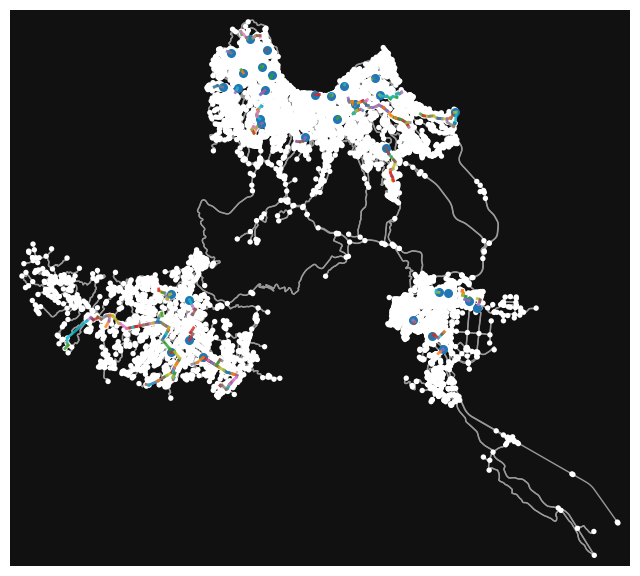

In [7]:
# Dibujar grafo y resaltar aristas instaladas y nodos de splitter
fig, ax = ox.plot_graph(G, show=False, close=False)
# Resaltar aristas instaladas
for (u,v) in installed_edges:
    xs = [G.nodes[u]['x'], G.nodes[v]['x']]
    ys = [G.nodes[u]['y'], G.nodes[v]['y']]
    ax.plot(xs, ys, linewidth=2, alpha=0.8)
# Resaltar splitters
splitter_points = [Point(G.nodes[s]['x'], G.nodes[s]['y']) for s in installed_splitters]
if splitter_points:
    splitter_gdf = gpd.GeoDataFrame(geometry=splitter_points, crs=nodes_gdf.crs)
    splitter_gdf.plot(ax=ax, markersize=30)

plt.show()